# Project - Mall Customer Segmentation with Machine Learning

## Introduction



## Objective

1. How to achieve customer segmentation using machine learning algorithm (KMeans CLustering) in Python
2. Who are your target customers with whom you can start marketing strategy
3. How the marketing strategy works in real world

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

from sklearn.cluster import KMeans


## Data Overview

In [2]:
# --- 1. Memuat data ---
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Data berhasil dimuat.")
    print(df.head())
except FileNotFoundError:
    print("File 'Mall_Customers.csv' tidak ditemukan. Pastikan file tersebut ada di direktori yang benar.")
    exit()

# --- 2. Menampilkan informasi dasar dataset ---
print("\nInformasi Dasar Dataset:")
print(df.info())

# --- 3. Menampilkan statistik deskriptif ---
print("\nStatistik Deskriptif:")
print(df.describe())

# --- 4. Mengecek nilai yang hilang ---
print("\nCek Nilai yang Hilang:")
print(df.isnull().sum())

# --- 5. Menghapus feature yang tidak diperlukan ---
df.drop(['CustomerID'], axis=1, inplace=True)
print("\nKolom 'CustomerID' telah dihapus.")

Data berhasil dimuat.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Informasi Dasar Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

St

## Exploratory Data Analysis

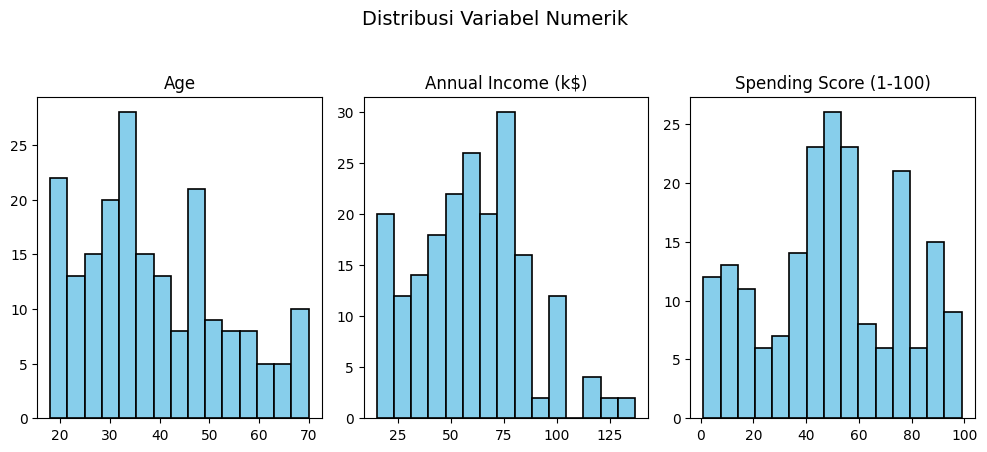


Visualisasi distribusi variabel numerik selesai.


In [3]:
# --- 1. Eksplorasi variabel ---
# Visualisasi distribusi variabel numerik
df_numeric = df.select_dtypes(include=[np.number])
axes = df_numeric.hist(
    figsize=(10, 8),
    bins=15,
    layout=(2, 3),
    edgecolor='black',
    linewidth=1.2,
    grid=False,
    color='skyblue'
)

fig = axes.flatten()[0].get_figure()
fig.suptitle('Distribusi Variabel Numerik', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nVisualisasi distribusi variabel numerik selesai.")

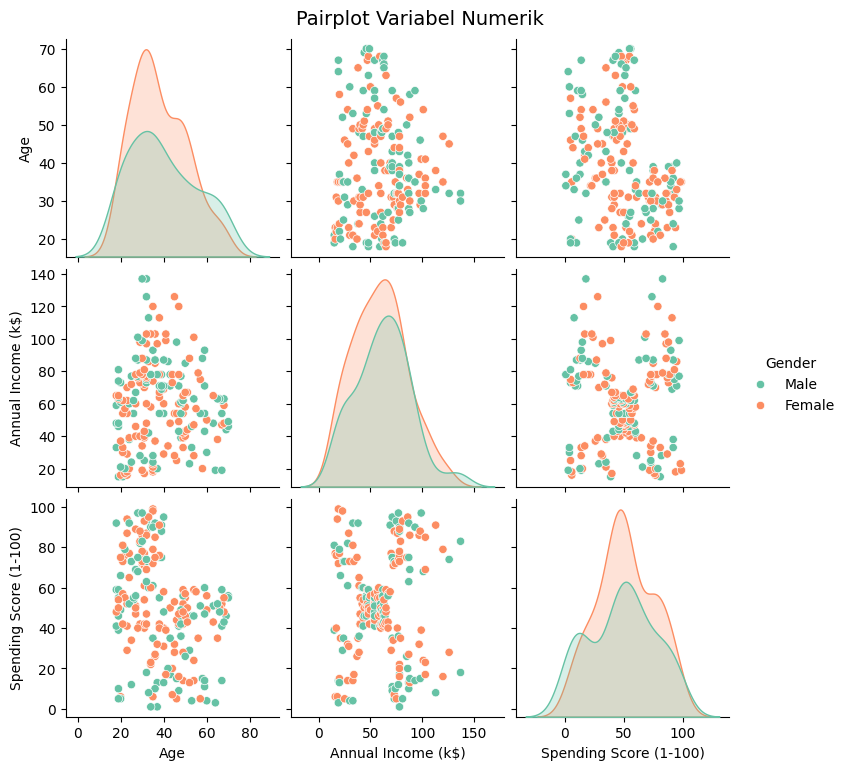


Visualisasi pairplot selesai.


In [4]:
# --- 2. Visualisasi hubungan antarvariabel dengan pairplot ---
sns.pairplot(df, hue='Gender', palette='Set2')
plt.suptitle('Pairplot Variabel Numerik', y=1.02, fontsize=14)
plt.show()
print("\nVisualisasi pairplot selesai.")

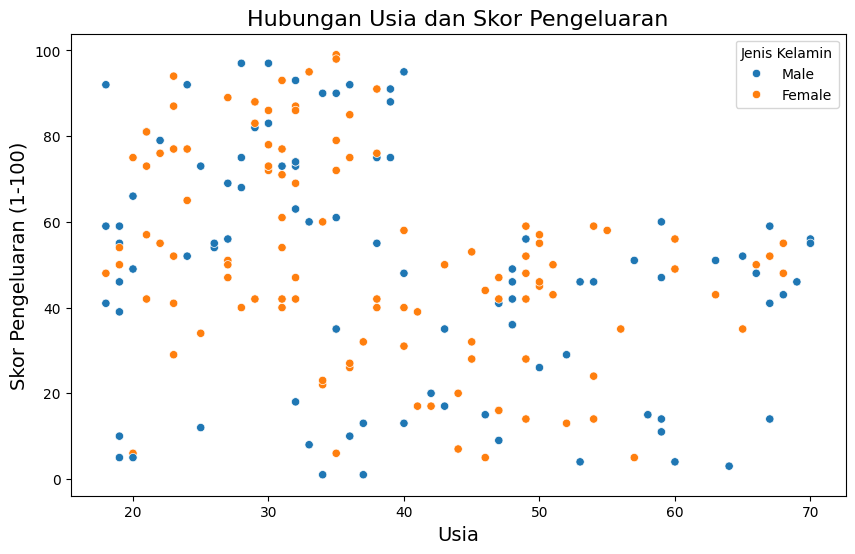

In [5]:
# --- 3. Visualisasi lanjutan Age vs Spending Score ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Gender')
plt.title('Hubungan Usia dan Skor Pengeluaran', fontsize=16)
plt.xlabel('Usia', fontsize=14)
plt.ylabel('Skor Pengeluaran (1-100)', fontsize=14)
plt.legend(title='Jenis Kelamin')
plt.show()

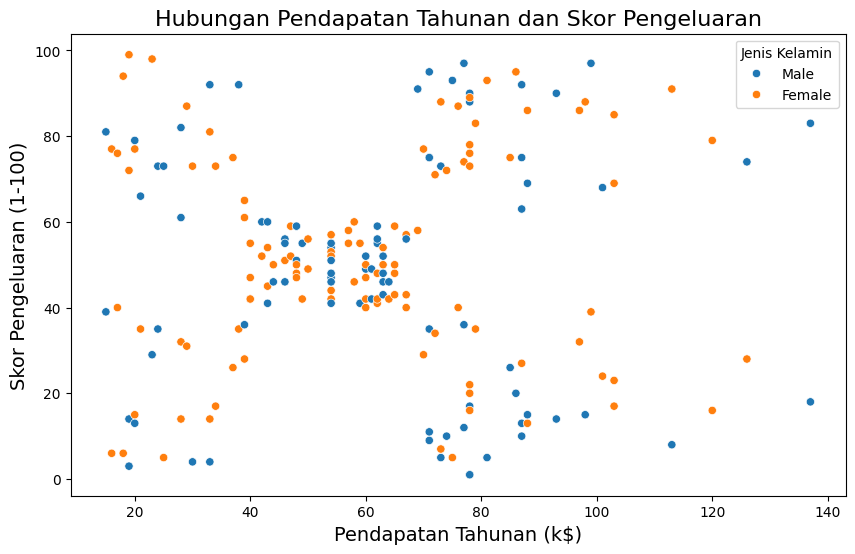

In [6]:
# --- 4. Visualisasi lanjutan Annual Income vs Spending Score ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Hubungan Pendapatan Tahunan dan Skor Pengeluaran', fontsize=16)
plt.xlabel('Pendapatan Tahunan (k$)', fontsize=14)
plt.ylabel('Skor Pengeluaran (1-100)', fontsize=14)
plt.legend(title='Jenis Kelamin')
plt.show()

## Building Model

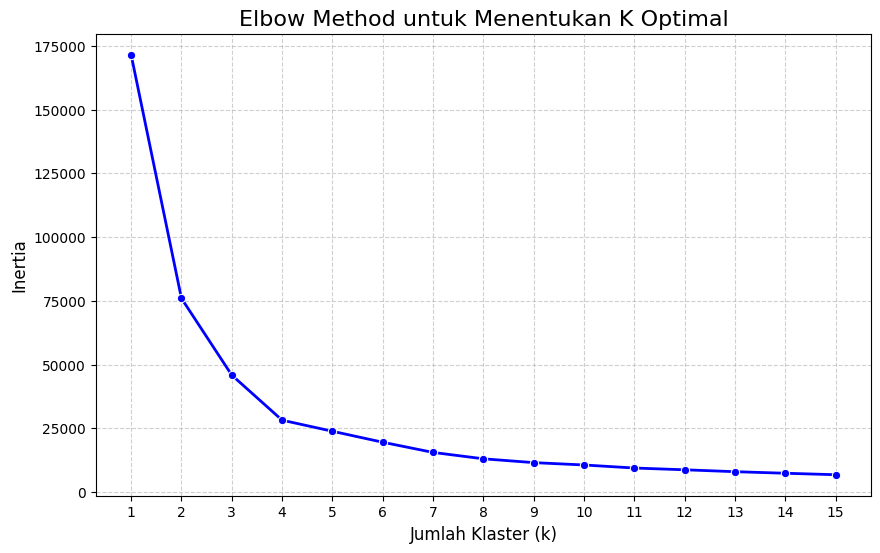

In [7]:
# --- 1. Persiapan Data ---
# Memilih fitur dan mengubahnya menjadi array NumPy
# Penggunaan .to_numpy() lebih modern daripada .values
# Menghilangkan .iloc[:, :] yang tidak perlu karena sudah memilih semua baris dan kolom
features = df[['Age', 'Spending Score (1-100)']].to_numpy()


# --- 2. Fungsi untuk Menghitung Inertia (Metode Siku) ---
def calculate_elbow_inertia(data, max_clusters):
    """
    Menghitung inertia untuk setiap jumlah klaster dari 1 hingga max_clusters.

    Args:
        data (np.array): Data fitur yang akan diklaster.
        max_clusters (int): Jumlah maksimum klaster yang akan diuji.

    Returns:
        list: Sebuah list berisi nilai inertia untuk setiap jumlah klaster.
    """
    inertia_values = []
    cluster_range = range(1, max_clusters + 1)
    
    for k in cluster_range:
        kmeans_model = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            max_iter=300,
            random_state=111,
            algorithm='lloyd' # 'elkan' bisa lebih cepat, 'lloyd' adalah default
        )
        kmeans_model.fit(data)
        inertia_values.append(kmeans_model.inertia_)
        
    return inertia_values, cluster_range

# --- 3. Eksekusi dan Visualisasi ---
# Tentukan jumlah maksimum klaster yang ingin diuji
MAX_K = 15
inertia, k_range = calculate_elbow_inertia(features, MAX_K)

# Visualisasi hasil untuk menemukan "siku"
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_range), y=inertia, marker='o', color='b', linewidth=2)
plt.title('Elbow Method untuk Menentukan K Optimal', fontsize=16)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:

# Asumsikan fungsi train_final_kmeans sudah ada dari sebelumnya
def train_final_kmeans(data, n_clusters, random_state=43):
    kmeans_final = KMeans(n_clusters=n_clusters, init='k-means++', random_state=random_state, n_init=10)
    kmeans_final.fit(data)
    labels = kmeans_final.labels_
    centroids = kmeans_final.cluster_centers_
    print(f"Model KMeans dengan {n_clusters} klaster berhasil dilatih untuk fitur yang relevan.")
    return kmeans_final, labels, centroids


def plot_cluster_boundaries(data_np, data_df, feature_names, labels, centroids, model):
    """
    Memvisualisasikan hasil clustering untuk DUA FITUR APAPUN.
    
    Args:
        data_np (np.array): Data fitur dalam format NumPy.
        data_df (pd.DataFrame): DataFrame asli untuk plotting.
        feature_names (list): List berisi dua nama kolom [nama_kolom_x, nama_kolom_y].
        labels (np.array): Label klaster untuk setiap data poin.
        centroids (np.array): Koordinat sentroid klaster.
        model (KMeans): Model KMeans yang sudah terlatih.
    """
    # 1. Siapkan meshgrid
    h = 0.5
    x_min, x_max = data_np[:, 0].min() - 5, data_np[:, 0].max() + 5
    y_min, y_max = data_np[:, 1].min() - 5, data_np[:, 1].max() + 5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Prediksi klaster untuk meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 3. Buat plot
    plt.figure(figsize=(15, 8))
    plt.clf()

    # Gambar latar belakang
    plt.imshow(Z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Pastel2, aspect='auto', origin='lower')

    # Gambar data poin secara dinamis menggunakan feature_names
    sns.scatterplot(x=feature_names[0], y=feature_names[1], data=data_df, hue=labels, palette='viridis', 
                    s=100, edgecolor='black', legend=False)

    # Gambar sentroid
    plt.scatter(x=centroids[:, 0], y=centroids[:, 1], s=300, c='red', 
                marker='o', edgecolor='black', label='Centroids')
    
    # Buat judul dan label sumbu secara dinamis
    plt.title(f'Klaster Pelanggan ({feature_names[0]} vs {feature_names[1]})', fontsize=18)
    plt.xlabel(feature_names[0], fontsize=14)
    plt.ylabel(feature_names[1], fontsize=14)
    plt.legend()
    plt.show()

--- Menganalisis Klaster berdasarkan Umur dan Skor Pengeluaran ---
Model KMeans dengan 4 klaster berhasil dilatih untuk fitur yang relevan.


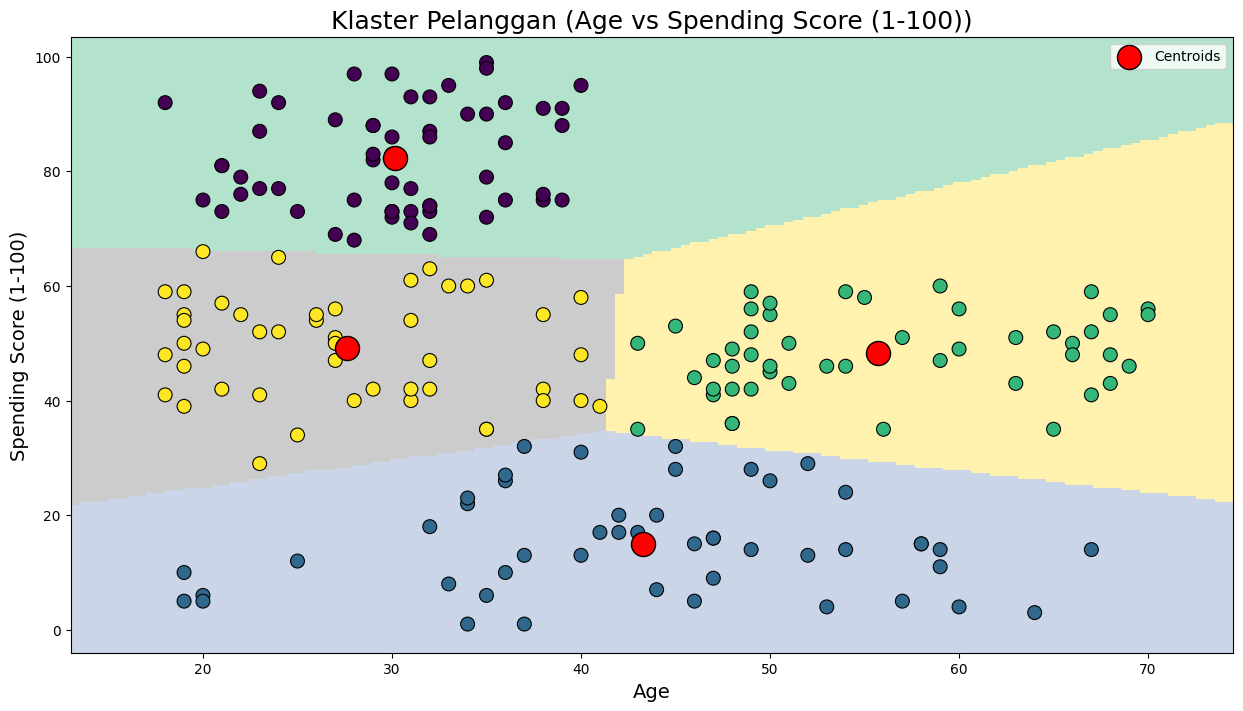

In [9]:
# --- KASUS 1: Umur vs Skor Pengeluaran ---
print("--- Menganalisis Klaster berdasarkan Umur dan Skor Pengeluaran ---")
# 1. Tentukan fitur
features_1_cols = ['Age', 'Spending Score (1-100)']
features_1_np = df[features_1_cols].to_numpy()

# 2. Latih model untuk set fitur ini
# Dari elbow method sebelumnya, kita asumsikan k=4 adalah optimal untuk kasus ini
model_1, labels_1, centroids_1 = train_final_kmeans(features_1_np, n_clusters=4)

# 3. Visualisasikan
plot_cluster_boundaries(features_1_np, df, features_1_cols, labels_1, centroids_1, model_1)



--- Menganalisis Klaster berdasarkan Pendapatan dan Skor Pengeluaran ---
Model KMeans dengan 5 klaster berhasil dilatih untuk fitur yang relevan.


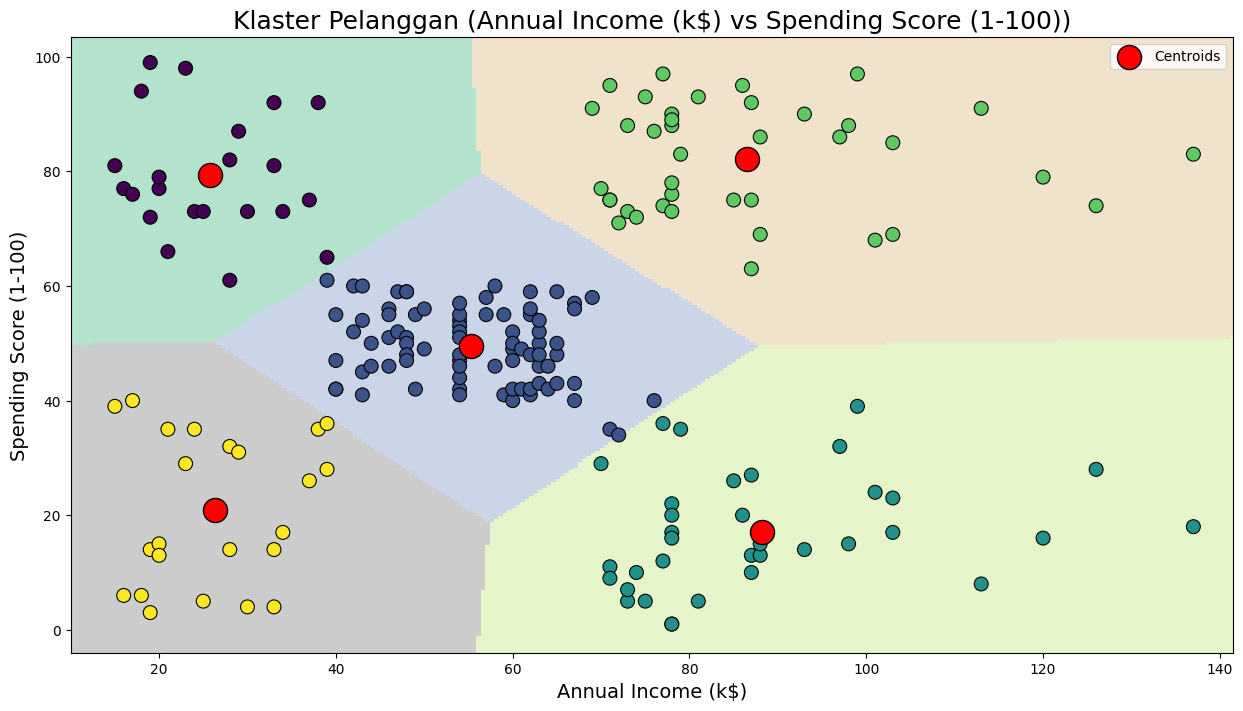

In [10]:
# --- KASUS 2: Pendapatan Tahunan vs Skor Pengeluaran ---
print("\n--- Menganalisis Klaster berdasarkan Pendapatan dan Skor Pengeluaran ---")
# 1. Tentukan fitur
features_2_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
features_2_np = df[features_2_cols].to_numpy()

# 2. Latih model BARU untuk set fitur ini (jumlah klaster optimal mungkin berbeda, di sini kita coba k=5)
model_2, labels_2, centroids_2 = train_final_kmeans(features_2_np, n_clusters=5)

# 3. Visualisasikan dengan fungsi yang SAMA
plot_cluster_boundaries(features_2_np, df, features_2_cols, labels_2, centroids_2, model_2)


--- Menganalisis Klaster berdasarkan Pendapatan, Umur, dan Skor Pengeluaran ---


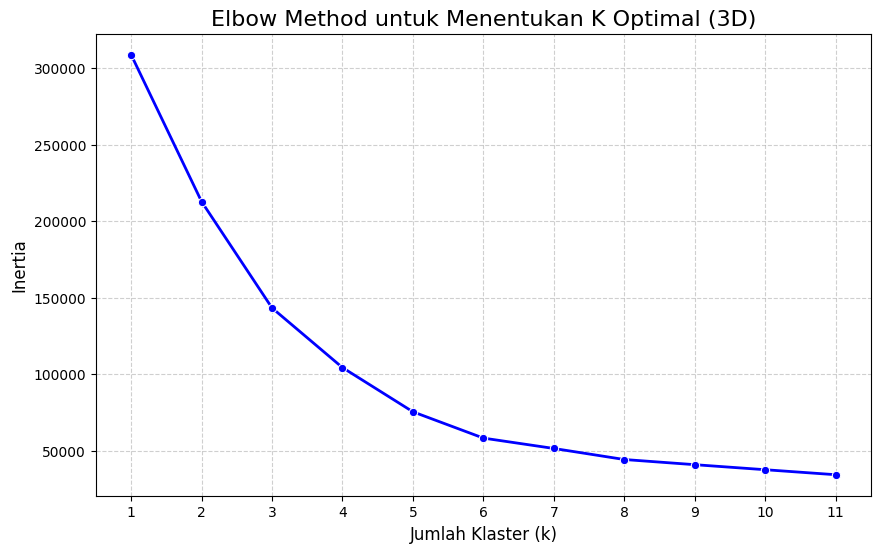

Model KMeans dengan 5 klaster berhasil dilatih untuk fitur yang relevan.
   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0    Male   19                  15                      39        0
1    Male   21                  15                      81        3
2  Female   20                  16                       6        0
3  Female   23                  16                      77        3
4  Female   31                  17                      40        0


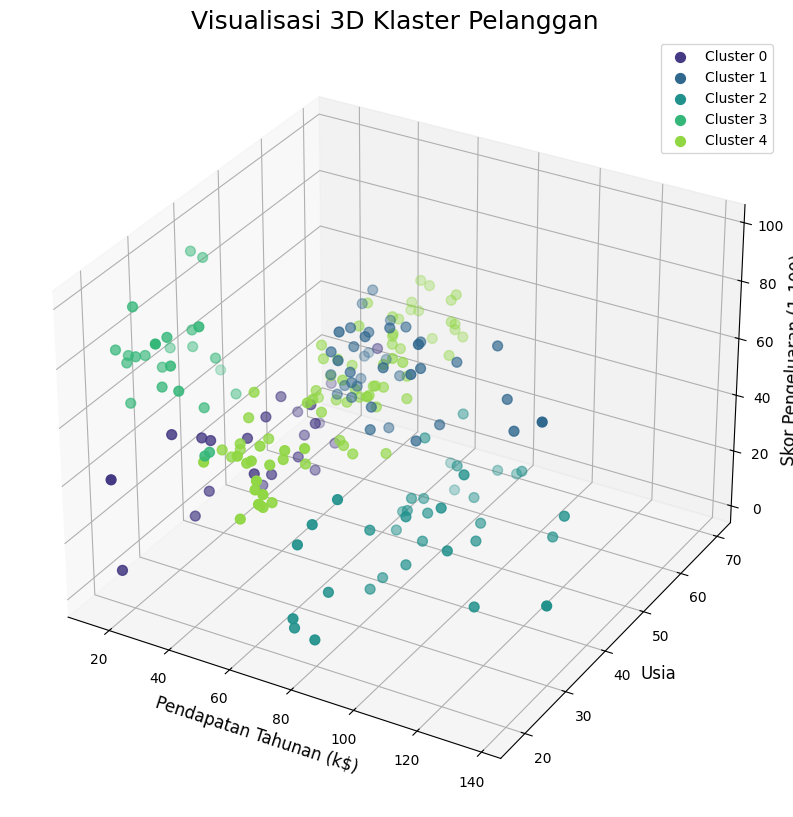

In [11]:
# --- KASUS 3: Persiapan data 3D ---
# --- 1. Persiapan Data 3D ---
print("\n--- Menganalisis Klaster berdasarkan Pendapatan, Umur, dan Skor Pengeluaran ---")
feature_3d_cols = ['Annual Income (k$)', 'Age', 'Spending Score (1-100)']
features_3d_np = df[feature_3d_cols].to_numpy()

# --- 2. Elbow Method untuk 3D ---
max_k_3d = 11
inertia_3d, k_range_3d = calculate_elbow_inertia(features_3d_np, max_k_3d)

# --- 3. Visualisasi Elbow Method untuk 3D ---
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_range_3d), y=inertia_3d, marker='o', color='b', linewidth=2)
plt.title('Elbow Method untuk Menentukan K Optimal (3D)', fontsize=16)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(list(k_range_3d))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 4. Latih model KMeans untuk 3D ---
n_clusters_3d = 5  # Misalnya kita pilih k=5 berdasarkan elbow method
final_model_3d, final_labels_3d, final_centroids_3d = train_final_kmeans(features_3d_np, n_clusters=n_clusters_3d)

# Menambahkan label klaster ke DataFrame untuk mempermudah visualisasi
df['Cluster'] = final_labels_3d
print(df.head())

# --- 5. Visualisasi 3D ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
colors = sns.color_palette('viridis', n_colors=df['Cluster'].nunique())

for i, color in enumerate(colors):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Age'],
               cluster_data['Spending Score (1-100)'],
               color=color, label=f'Cluster {i}', s=50)
ax.set_title('Visualisasi 3D Klaster Pelanggan', fontsize=18)
ax.set_xlabel('Pendapatan Tahunan (k$)', fontsize=12)
ax.set_ylabel('Usia', fontsize=12)
ax.set_zlabel('Skor Pengeluaran (1-100)', fontsize=12)
ax.legend()
plt.show()

In [17]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# Asumsikan 'df' adalah DataFrame Anda dan sudah memiliki kolom 'Cluster_3D' 

# --- 1. Inisialisasi dan Persiapan ---
data_traces = []
unique_clusters = sorted(df['Cluster'].unique())

# --- PERBAIKAN DI SINI ---
# Mengganti 'Vibrant' dengan 'Plotly' (palet default) atau 'Set2'
colors = px.colors.qualitative.Plotly 

# --- 2. Perulangan untuk Membuat Trace per Klaster ---
for i, cluster_label in enumerate(unique_clusters):
    cluster_df = df[df['Cluster'] == cluster_label]
    
    trace = go.Scatter3d(
        x=cluster_df['Annual Income (k$)'],
        y=cluster_df['Age'],
        z=cluster_df['Spending Score (1-100)'],
        mode='markers',
        marker=dict(
            size=6,
            color=colors[i],
            opacity=0.8
        ),
        name=f'Klaster {cluster_label}'
    )
    data_traces.append(trace)

# --- 3. Pengaturan Layout dan Pembuatan Figure ---
layout = go.Layout(
    title='Visualisasi 3D Klaster Pelanggan',
    scene=dict(
        xaxis_title='Pendapatan Tahunan (k$)',
        yaxis_title='Usia',
        zaxis_title='Skor Pengeluaran (1-100)'
    ),
    legend_title_text='Daftar Klaster'
)

fig = go.Figure(data=data_traces, layout=layout)

# --- 4. Tampilkan Plot ---
fig.show()